In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

RAW_FILEPATH = "data/001_raw/P_data.mat"
CLEANED_FILEPATH = "data/002_cleaned/1s_power_load.parquet"

def engineered_filepath(res: str) -> str:
    return f"data/003_engineered/{res}_power_load.parquet"

### Step 1: Clean Data

Process raw data into a clean structured dataframe

In [97]:
raw_data = loadmat(RAW_FILEPATH)
raw_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 26 17:25:22 2026',
 '__version__': '1.0',
 '__globals__': [],
 'P_data': array([[1925., 1301., 1320., ..., 2123., 2606., 1318.],
        [1922., 1296., 1320., ..., 2126., 2601., 1317.],
        [1921., 1285., 1316., ..., 2121., 2607., 1316.],
        ...,
        [1253., 1315., 1518., ..., 2615., 1321., 1446.],
        [1248., 1315., 1506., ..., 2613., 1320., 1469.],
        [1249., 1317., 1516., ..., 2605., 1320., 1463.]], shape=(86400, 31)),
 'day_data': array([[array(['2025/11/28'], dtype='<U10'),
         array(['2025/11/29'], dtype='<U10'),
         array(['2025/11/30'], dtype='<U10'),
         array(['2025/12/01'], dtype='<U10'),
         array(['2025/12/02'], dtype='<U10'),
         array(['2025/12/03'], dtype='<U10'),
         array(['2025/12/04'], dtype='<U10'),
         array(['2025/12/05'], dtype='<U10'),
         array(['2025/12/06'], dtype='<U10'),
         array(['2025/12/07'], dtype='<U10'),
     

**Restructure Data**:

Transform raw data into a structured dataframe

| Column | Description |
| --- | --- |
| `timestamp` | Timestamp of when the power load was recorded |
| `load` | Power load recorded, in Watts |
| `day_class` | Type of workday (`full`, `half`, `none`) |

In [98]:
# Transform raw data into a dataframe
raw_p_data = raw_data["P_data"]
raw_day_data = raw_data["day_data"]
raw_day_class = raw_data["day_class"]

columns = pd.to_datetime([d[0] for d in raw_day_data.squeeze()])
df = (
    pd.DataFrame(raw_p_data, columns=columns)
    .assign(second_of_day=np.arange(86400))
    .melt(id_vars="second_of_day", var_name="date", value_name="load")
    .assign(
        date=lambda x: pd.to_datetime(x["date"]),
        timestamp=lambda x: x["date"]
        + pd.to_timedelta(x["second_of_day"], unit="s")
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Add day class labels
day_class_df = pd.DataFrame({
    "date": pd.to_datetime([d[0] for d in raw_day_data.squeeze()]),
    "day_class": [d[0] for d in raw_day_class.squeeze()]
})

df = df.merge(
    day_class_df,
    left_on=pd.to_datetime(df["timestamp"].dt.date),
    right_on="date",
    how="left"
)

df = df[["timestamp", "load", "day_class"]]

print(df.shape)
df.head()

(2678400, 3)


,timestamp,load,day_class
0,2025-11-28 00:00:00,1925.0,full
1,2025-11-28 00:00:01,1922.0,full
2,2025-11-28 00:00:02,1921.0,full
3,2025-11-28 00:00:03,1921.0,full
4,2025-11-28 00:00:04,1926.0,full


**Missing Power Load**:

Missing power load values represent errors in the device recording the power load. For our model approach, we will keep them as `NaN` values because they represent truth of the data. We will filter out missing power load values during training.

Number of missing load values: 14576 (0.54% of dataset)


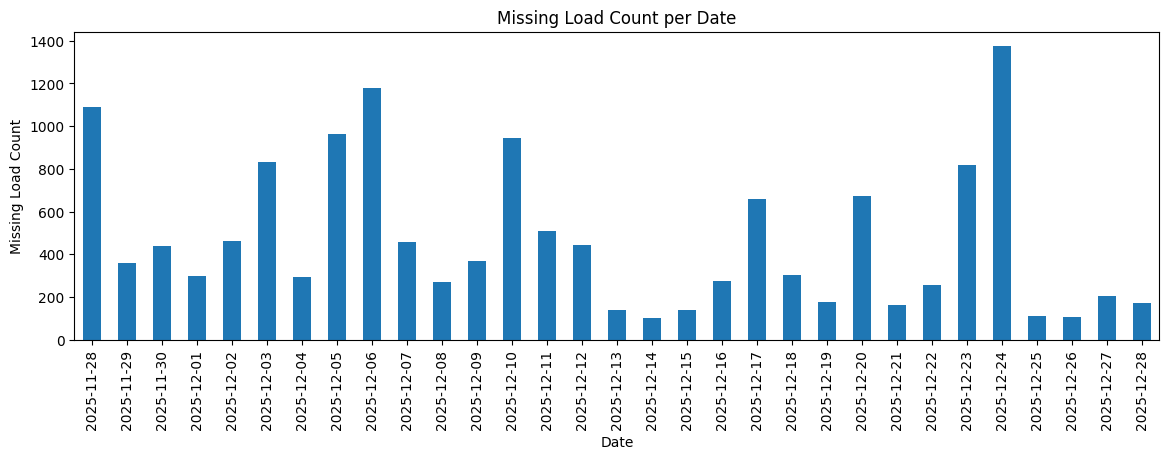

In [99]:
# Check for missing load values
missing_load_df = df[df["load"].isna()]
missing_load_count = missing_load_df.shape[0]
print(f"Number of missing load values: {missing_load_count} ({missing_load_count / df.shape[0] * 100:.2f}% of dataset)")

# Plot missing load count per date (including dates with 0 missing values)
missing_load_count_per_date = missing_load_df.groupby(missing_load_df["timestamp"].dt.date).size()
date_range = pd.date_range(start=df["timestamp"].min().date(), end=df["timestamp"].max().date(), freq="D").date
missing_load_count_per_date = missing_load_count_per_date.reindex(date_range, fill_value=0)
missing_load_count_per_date.plot(kind="bar", figsize=(14, 4))
plt.xlabel("Date")
plt.ylabel("Missing Load Count")
plt.title("Missing Load Count per Date")
plt.show()


**Zero Power Load**:

Zero power load values represent 0 watts recorded at the given time interval. This is an accurate reading of the device and will be left as 0.

Number of missing load values: 2682 (0.10% of dataset)


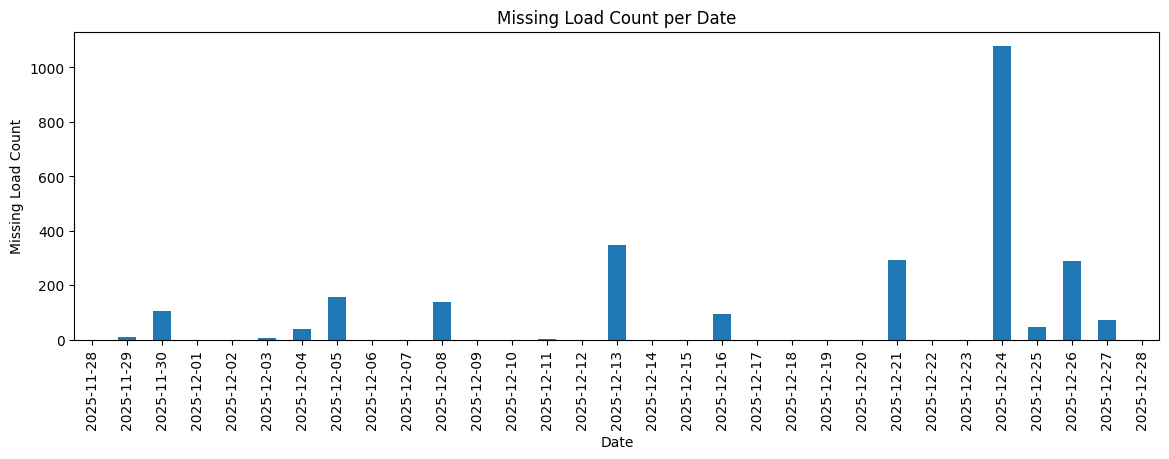

In [100]:
# Check for missing load values
zero_load_df = df[df["load"] == 0]
zero_load_count = zero_load_df.shape[0]
print(f"Number of missing load values: {zero_load_count} ({zero_load_count / df.shape[0] * 100:.2f}% of dataset)")

# Plot missing load count per date (including dates with 0 missing values)
zero_load_count_per_date = zero_load_df.groupby(zero_load_df["timestamp"].dt.date).size()
date_range = pd.date_range(start=df["timestamp"].min().date(), end=df["timestamp"].max().date(), freq="D").date
zero_load_count_per_date = zero_load_count_per_date.reindex(date_range, fill_value=0)
zero_load_count_per_date.plot(kind="bar", figsize=(14, 4))
plt.xlabel("Date")
plt.ylabel("Missing Load Count")
plt.title("Missing Load Count per Date")
plt.show()


**Outliers**

We assume the power load data is accurate and high outliers represent true readings of the machine. There doesn't appear to be any values that seem inaccurate or of concern.

Number of high load values: 26636 (0.99% of dataset)


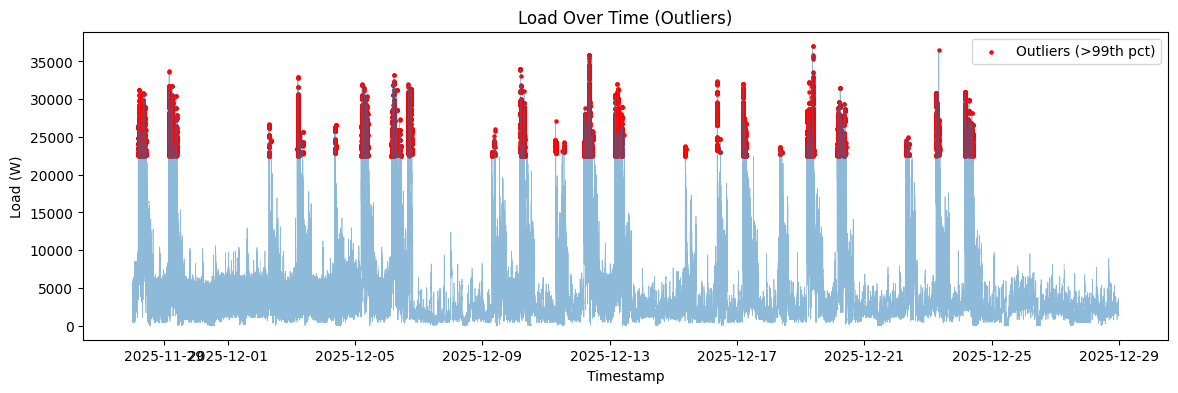

In [101]:
# Identify high load values (e.g. above 99th percentile)
high_load_threshold = df["load"].quantile(0.99)
high_load_df = df[df["load"] > high_load_threshold]
high_load_count = high_load_df.shape[0]
print(f"Number of high load values: {high_load_count} ({high_load_count / df.shape[0] * 100:.2f}% of dataset)")
high_load_df

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["load"], alpha=0.5, linewidth=0.5)
plt.scatter(high_load_df["timestamp"], high_load_df["load"], color="red", s=5, label="Outliers (>99th pct)")
plt.title("Load Over Time (Outliers)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend()
plt.show()

In [ ]:
# Save cleaned dataframe
df.to_parquet(CLEANED_FILEPATH, index=False)

### Step 2: EDA

Explore data to identify trends and help plan model and feature selections

In [103]:
df = pd.read_parquet(CLEANED_FILEPATH)
print(df.shape)
df.head()

(2678400, 3)


,timestamp,load,day_class
0,2025-11-28 00:00:00,1925.0,full
1,2025-11-28 00:00:01,1922.0,full
2,2025-11-28 00:00:02,1921.0,full
3,2025-11-28 00:00:03,1921.0,full
4,2025-11-28 00:00:04,1926.0,full


In [104]:
df.dtypes

timestamp    datetime64[ns]
load                float64
day_class            object
dtype: object

In [105]:
# Add some features for EDA
df["day_of_week"] = df["timestamp"].dt.day_name()
df["hour_of_day"] = df["timestamp"].dt.hour
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"
df["time_of_day"] = df["timestamp"].dt.hour.apply(time_of_day)
df["is_weekend"] = df["timestamp"].dt.dayofweek.isin([5, 6]).map({True: "Weekend", False: "Weekday"})
df.head()

,timestamp,load,day_class,day_of_week,hour_of_day,time_of_day,is_weekend
0,2025-11-28 00:00:00,1925.0,full,Friday,0,Night,Weekday
1,2025-11-28 00:00:01,1922.0,full,Friday,0,Night,Weekday
2,2025-11-28 00:00:02,1921.0,full,Friday,0,Night,Weekday
3,2025-11-28 00:00:03,1921.0,full,Friday,0,Night,Weekday
4,2025-11-28 00:00:04,1926.0,full,Friday,0,Night,Weekday


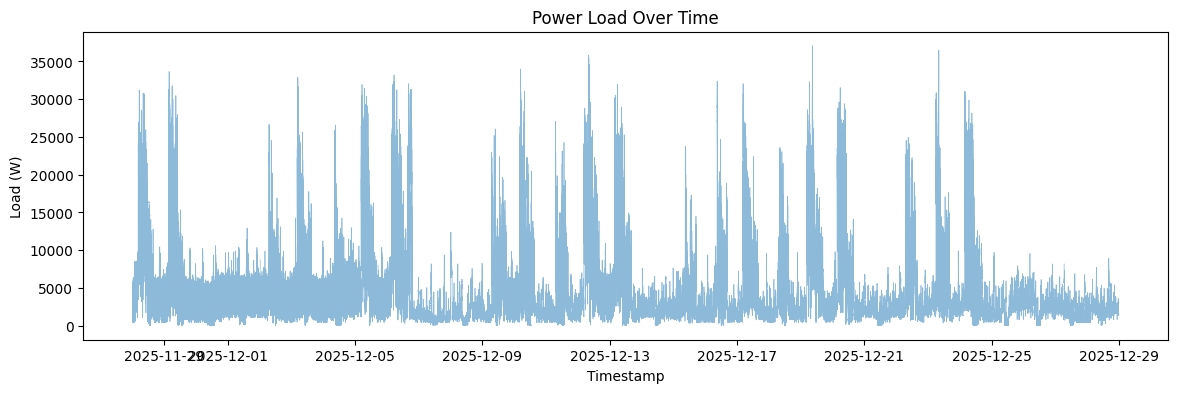

In [106]:
# Plot power load timeseries
plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["load"], alpha=0.5, linewidth=0.5)
plt.title("Power Load Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.show()

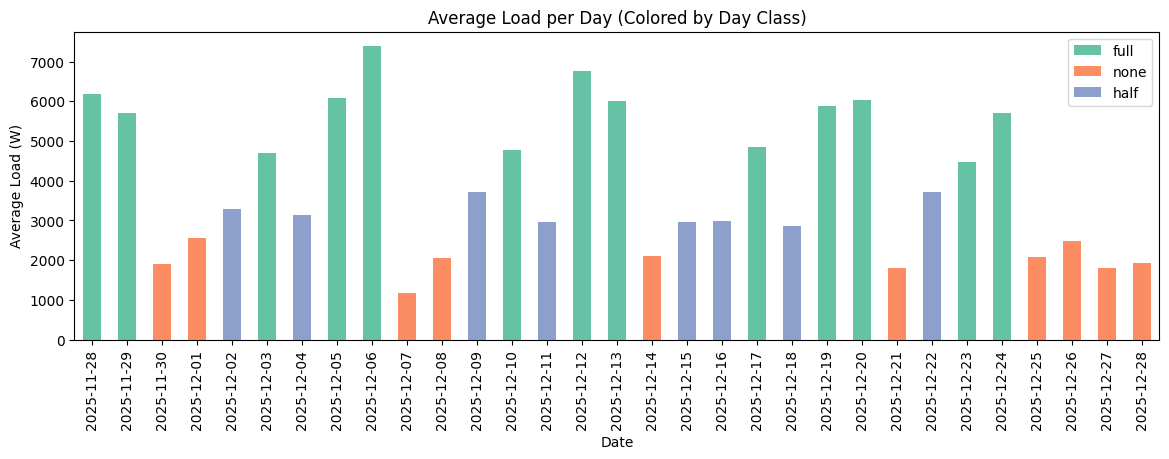

In [107]:
# Plot average load per day (colored by day class)
daily_load = df.groupby(df["timestamp"].dt.date)["load"].mean()
daily_dates = daily_load.index

# Get the day_class for each date
day_classes_per_date = df.groupby(df["timestamp"].dt.date)["day_class"].first()

# Create color map for day classes
unique_classes = df["day_class"].unique()
color_map = {cls: color for cls, color in zip(unique_classes, plt.cm.Set2(range(len(unique_classes))))}
colors = [color_map[day_classes_per_date[date]] for date in daily_dates]

plt.figure(figsize=(14, 4))
daily_load.plot(kind="bar", color=colors)
plt.title("Average Load per Day (Colored by Day Class)")
plt.xlabel("Date")
plt.ylabel("Average Load (W)")

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cls], label=cls) for cls in unique_classes]
plt.legend(handles=legend_elements)
plt.show()


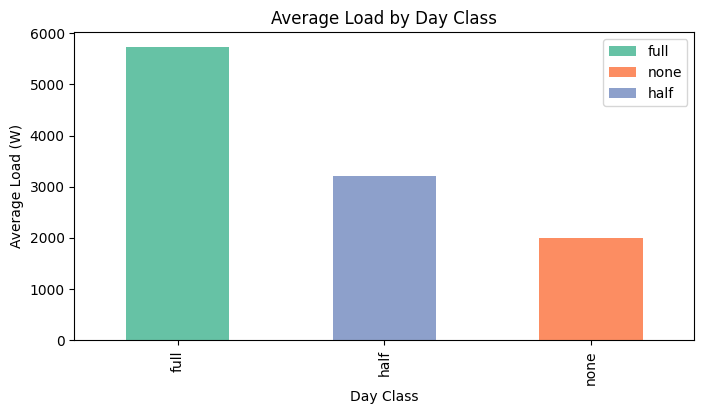

In [108]:
# Plot average load by day class
plt.figure(figsize=(8, 4))

# Create color map for day classes
unique_classes = df["day_class"].unique()
color_map = {cls: color for cls, color in zip(unique_classes, plt.cm.Set2(range(len(unique_classes))))}
colors = [color_map[cls] for cls in df.groupby("day_class")["load"].mean().index]

df.groupby("day_class")["load"].mean().plot(kind="bar", color=colors)
plt.title("Average Load by Day Class")
plt.xlabel("Day Class")
plt.ylabel("Average Load (W)")

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cls], label=cls) for cls in unique_classes]
plt.legend(handles=legend_elements)
plt.show()


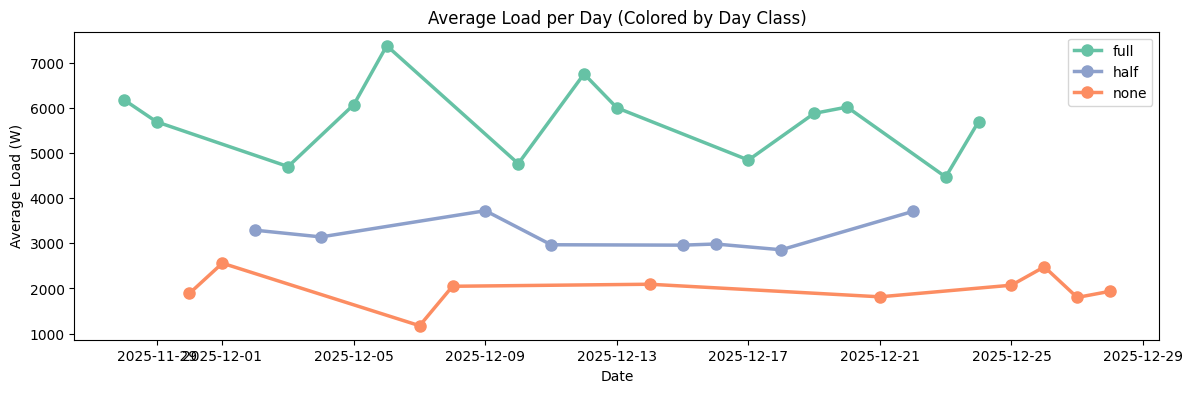

In [109]:
# Plot average load per day (colored by day class)
plt.figure(figsize=(14, 4))

# Create color map for day classes
unique_classes = df["day_class"].unique()
color_map = {cls: color for cls, color in zip(unique_classes, plt.cm.Set2(range(len(unique_classes))))}

for day_class, group in df.groupby("day_class"):
    group.groupby(group["timestamp"].dt.date)["load"].mean().plot(label=day_class, color=color_map[day_class], linewidth=2.5, marker="o", markersize=8)

plt.title("Average Load per Day (Colored by Day Class)")
plt.xlabel("Date")
plt.ylabel("Average Load (W)")
plt.legend()
plt.show()


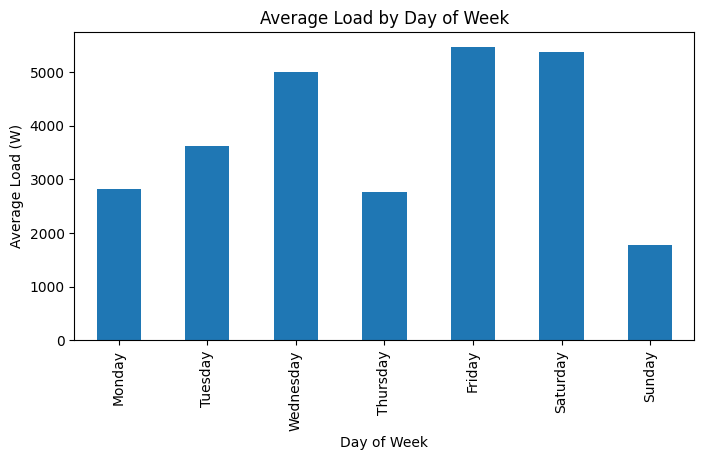

In [110]:
# Plot average load by day of week
plt.figure(figsize=(8, 4))
df.groupby("day_of_week")["load"].mean().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).plot(kind="bar")
plt.title("Average Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Load (W)")
plt.show()

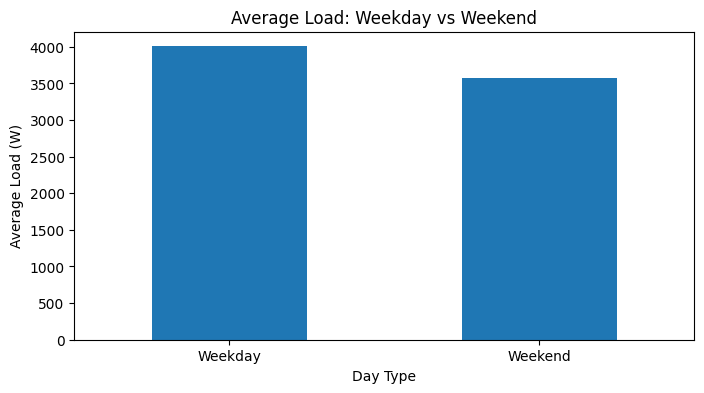

In [111]:
# Plot average load by weekend vs non weekend
plt.figure(figsize=(8, 4))
df.groupby("is_weekend")["load"].mean().plot(kind="bar")
plt.title("Average Load: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Load (W)")
plt.xticks(rotation=0)
plt.show()


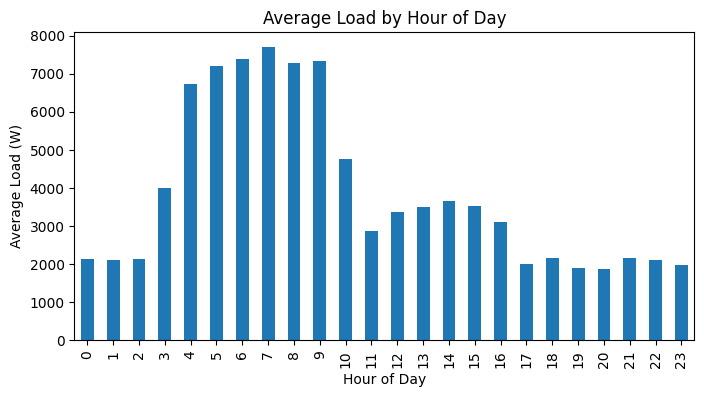

In [112]:
# Plot average load by hour of the day
plt.figure(figsize=(8, 4))
df.groupby("hour_of_day")["load"].mean().plot(kind="bar")
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (W)")
plt.show()

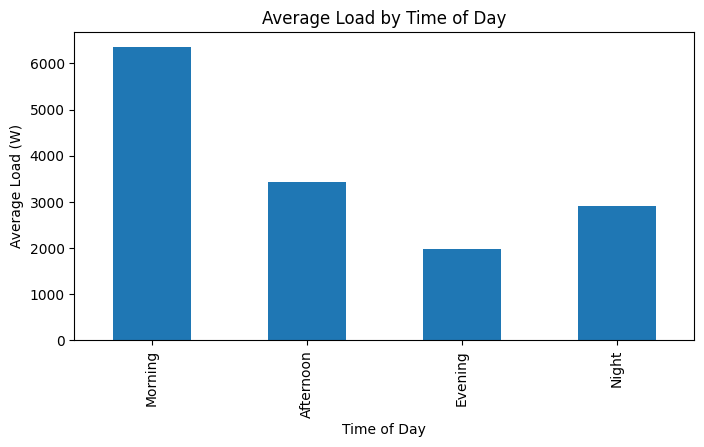

In [113]:
# Plot average load by time of day (morning, afternoon, evening, night)
plt.figure(figsize=(8, 4))
df.groupby("time_of_day")["load"].mean().reindex(["Morning", "Afternoon", "Evening", "Night"]).plot(kind="bar")
plt.title("Average Load by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Load (W)")
plt.show()

### Step 3: Feature Engineering

Create features for the model

In [117]:
clean_df = pd.read_parquet(CLEANED_FILEPATH)
print(clean_df.shape)
clean_df.head()

(2678400, 3)


,timestamp,load,day_class
0,2025-11-28 00:00:00,1925.0,full
1,2025-11-28 00:00:01,1922.0,full
2,2025-11-28 00:00:02,1921.0,full
3,2025-11-28 00:00:03,1921.0,full
4,2025-11-28 00:00:04,1926.0,full


---
**Resample data per resolution**:

Our data is in 1-second intervals.

We want to resmaple the data to higher resolution intervals for better predictions, such as 30 sec, 1 min, 2 min, 5 min, etc

| **Resolution** | **Description** |
| --- | --- |
| `30s` | 30-second intervals |
| `1min` | 1-minute intervals |
| `2min` | 2-minute intervals |
| `5min` | 5-minute intervals |
| `10min` | 10-minute intervals |
| `15min` | 15-minute intervals |

Each resample of resolution calculates the average of `load` for that resolution

---

**1. Temporal Features**:

Features relating to the time and day

| Column       | Type    | Description |
|-------------|---------|-------------|
| `hour` | int | Hour of the day (0,1,...,23) |
| `time_of_day` | string | Time of the day (Morning, Afternoon, Evening, Night)|
| `day`         | int     | Day of month (1–31) |
| `weekday`     | int     | Day of week (0=Mon … 6=Sun) |
| `is_weekend`  | int    | 1 if Saturday or Sunday, 0 otherwise |
| `month`       | int     | Month of year (1=Jan, 2=Feb, ... 12=Dec) |

---

**2. Business Features**:

Features related to the business operations:

| Column | Description |
|--------|-------------|
| `workday` | Type of workday (`full`, `half`, `none`) |

---

**3. Historic Load Features**

Features describe how power load has behaved in the past, across three dimensions:

**Snapshot** — what load was at a specific point in the past

| Column | Description |
|--------|-------------|
| `lag_X` | Load value exactly X intervals ago |

**Window Statistics** — summary of load behavior over a recent period

| Column | Description |
|--------|-------------|
| `rolling_mean_X` | Average load over the past X intervals |
| `rolling_std_X` | How much load varied over the past X intervals |
| `rolling_max_X` | Highest load seen over the past X intervals |
| `rolling_min_X` | Lowest load seen over the past X intervals |

**Trend** — how load is changing over time

| Column | Description |
|--------|-------------|
| `delta_X` | Load change between X intervals ago and 1 interval ago |
| `slope_X` | Rate of change in load over the past X intervals (linear trend) |

`X` represents number of time interval (depending on the resolution)
- 1 min resolution: 1X = 1 minute, 2X = 2 minute, etc
- 5 min resolution: 1X = 5 minutes, 2X = 10 minutes, etc


In [118]:
# ---------------------------------------------------------------
# Feature Config
# ---------------------------------------------------------------
RESAMPLE_RESOLUTIONS = ["30s", "1min", "2min", "5min", "10min"]
LAG_INTERVALS = [1, 2, 3, 4, 5, 10, 15, 30, 60]
WINDOW_INTERVALS = [5, 15, 30, 60]

# ---------------------------------------------------------------
# Resample By Resolution
# ---------------------------------------------------------------
def resample_data(df: pd.DataFrame, resolution: str) -> pd.DataFrame:
    """Resample to target resolution by averaging load per interval."""
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp")
    df = df["load"].resample(resolution).mean()
    df = df.reset_index()
    return df

# ---------------------------------------------------------------
# 1. Temporal Features
# ---------------------------------------------------------------
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df["hour"] = df["timestamp"].dt.hour
    df["time_of_day"] = df["hour"].apply(time_of_day)
    df["day"] = df["timestamp"].dt.day
    df["weekday"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = df["timestamp"].dt.dayofweek.isin([5, 6]).astype(int)
    df["month"] = df["timestamp"].dt.month
    return df

# ---------------------------------------------------------------
# 2. Business Features
# ---------------------------------------------------------------
day_class_map = clean_df.groupby(clean_df["timestamp"].dt.date)["day_class"].first()

def add_business_features(df: pd.DataFrame) -> pd.DataFrame:
    df["workday"] = df["timestamp"].dt.date.map(day_class_map)
    return df

# ---------------------------------------------------------------
# 3. Historic Load Features
# ---------------------------------------------------------------
def add_lag_features(df: pd.DataFrame, intervals: list) -> pd.DataFrame:
    for x in intervals:
        df[f"lag_{x}"] = df["load"].shift(x)
    return df

def add_rolling_features(df: pd.DataFrame, windows: list) -> pd.DataFrame:
    for x in windows:
        df[f"rolling_mean_{x}"] = df["load"].shift(1).rolling(x).mean()
        df[f"rolling_std_{x}"]  = df["load"].shift(1).rolling(x).std()
        df[f"rolling_max_{x}"]  = df["load"].shift(1).rolling(x).max()
        df[f"rolling_min_{x}"]  = df["load"].shift(1).rolling(x).min()
    return df

def add_delta_features(df: pd.DataFrame, intervals: list) -> pd.DataFrame:
    for x in intervals:
        df[f"delta_{x}"] = df["load"].shift(1) - df["load"].shift(x)
    return df

def add_slope_features(df: pd.DataFrame, intervals: list) -> pd.DataFrame:
    def _slope(arr):
        if np.isnan(arr).any():
            return np.nan
        x = np.arange(len(arr))
        return np.polyfit(x, arr, 1)[0]

    for x in intervals:
        df[f"slope_{x}"] = (
            df["load"].shift(1).rolling(x).apply(_slope, raw=True)
        )
    return df

def add_historic_load_features(df: pd.DataFrame) -> pd.DataFrame:
    df = add_lag_features(df, LAG_INTERVALS)
    df = add_rolling_features(df, WINDOW_INTERVALS)
    df = add_delta_features(df, WINDOW_INTERVALS)
    df = add_slope_features(df, WINDOW_INTERVALS)

    return df

# ---------------------------------------------------------------
# Resample and Engineer Features by Resolution
# ---------------------------------------------------------------
dfs = {}

print("Resolution Datasets:")
for res in RESAMPLE_RESOLUTIONS:
    print(res, ":", end=" ")
    df = resample_data(clean_df, res)
    df = add_business_features(df)
    df = add_historic_load_features(df)
    df = add_temporal_features(df)
    dfs[res] = df
    print(df.shape)

Resolution Datasets:
30s : (89280, 42)
1min : (44640, 42)
2min : (22320, 42)
5min : (8928, 42)
10min : (4464, 42)


In [119]:
dfs["1min"].head()

,timestamp,load,workday,lag_1,lag_2,lag_3,lag_4,lag_5,lag_10,lag_15,...,slope_5,slope_15,slope_30,slope_60,hour,time_of_day,day,weekday,is_weekend,month
0,2025-11-28 00:00:00,1912.400000,full,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,Night,28,4,0,11
1,2025-11-28 00:01:00,1908.233333,full,1912.400000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,Night,28,4,0,11
2,2025-11-28 00:02:00,1643.183333,full,1908.233333,1912.400000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,Night,28,4,0,11
3,2025-11-28 00:03:00,2992.950000,full,1643.183333,1908.233333,1912.400000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,Night,28,4,0,11
4,2025-11-28 00:04:00,1106.000000,full,2992.950000,1643.183333,1908.233333,1912.4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,Night,28,4,0,11


In [120]:
dfs["1min"].dtypes

timestamp          datetime64[ns]
load                      float64
workday                    object
lag_1                     float64
lag_2                     float64
lag_3                     float64
lag_4                     float64
lag_5                     float64
lag_10                    float64
lag_15                    float64
lag_30                    float64
lag_60                    float64
rolling_mean_5            float64
rolling_std_5             float64
rolling_max_5             float64
rolling_min_5             float64
rolling_mean_15           float64
rolling_std_15            float64
rolling_max_15            float64
rolling_min_15            float64
rolling_mean_30           float64
rolling_std_30            float64
rolling_max_30            float64
rolling_min_30            float64
rolling_mean_60           float64
rolling_std_60            float64
rolling_max_60            float64
rolling_min_60            float64
delta_5                   float64
delta_15      

In [ ]:
# save each engineered dataset
for res, df in dfs.items():
    df.to_parquet(engineered_filepath(res), index=False)

### Step 4: Model Preprocessing

Preprocess each\